# KRITTIKA SUMMER PROJECT 2022 

Krittika's Python tutorial notebooks: https://github.com/krittikaiitb/tutorials <br><br>
A Cepheid variable is a type of star that, due to some inherent instability, pulsates radially, varying in both diameter and temperature and producing changes in brightness with a well-defined stable period and amplitude. As it turns out, the period of pulsation and the Luminosity (i.e the absolute magnitude) of the Cephied are related. <br><br>
We'll use data of cepheids from the Small Magallenic Cloud (SMC) obtained by a survey called Optical Gravitational Lensing Experiment (OGLE).The Small Magellanic Cloud is a dwarf galaxy satellite of the Milky Way, and distances to any star in it can be assumed to be almost constant. So the magnitudes translated directly into absolute magnitudes with some offset dependent on the distance to the SMC!

# Data Cleaning

The data file given consists of 'ID', the identifier for the star; 'RA', the right ascension in HMS format; 'Decl', the declination in DMS format; 'I' , the I band magnitude; 'V', the V band magnitude; 'P_1', the period. <br><br>
Some entries in the V and I band magnitude have a value of -99.990, thus these will be removed for further analysis.  

### Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

### Removal of unwanted Entries

In [2]:
df = pd.read_csv(r"CepheidData.csv")
df = df[~df.V.isin([-99.990])]
df = df[~df.I.isin([-99.990])]
df.reset_index(inplace = True)
df

,index,ID,RA,Decl,I,V,P_1
0,0,OGLE-SMC-CEP-0001,00:20:07.87,-74:32:54.6,17.314,17.897,1.128258
1,1,OGLE-SMC-CEP-0005,00:21:53.88,-72:22:22.7,17.196,17.768,1.287411
2,2,OGLE-SMC-CEP-0006,00:21:56.36,-73:54:55.9,17.120,17.770,1.484773
3,4,OGLE-SMC-CEP-0009,00:22:25.60,-73:47:03.5,16.814,17.384,1.639233
4,5,OGLE-SMC-CEP-0010,00:22:29.29,-73:54:16.3,16.976,17.515,1.442611
...,...,...,...,...,...,...,...
2632,2741,OGLE-SMC-CEP-4967,00:56:34.60,-77:55:13.2,17.328,18.067,1.012830
2633,2749,OGLE-SMC-CEP-4983,01:50:40.50,-70:30:13.0,15.224,15.834,4.372303
2634,2750,OGLE-SMC-CEP-4985,01:56:47.74,-73:49:37.1,14.063,14.929,8.040087
2635,2752,OGLE-SMC-CEP-4987,03:31:34.40,-70:59:38.2,15.738,16.458,2.928475


### Conversion of RA and Dec values to degrees from HMS and DMS respectively

In [3]:
def HMS_to_decimal(x):
    h,m,s = map(float,x.split(':'))
    degrees = (h+(m/60)+(s/3600))*(360/24)
    if degrees > 180:
        return degrees - 360
    else:
        return degrees
df['RA'] = df['RA'].apply(lambda x: HMS_to_decimal(x))

def DMS_to_decimal(x):
    d,m,s = map(float,x.split(':'))
    return (d+(m/60)+(s/3600))
df['Decl'] = df['Decl'].apply(lambda x: DMS_to_decimal(x))
df

,index,ID,RA,Decl,I,V,P_1
0,0,OGLE-SMC-CEP-0001,5.032792,-73.451500,17.314,17.897,1.128258
1,1,OGLE-SMC-CEP-0005,5.474500,-71.627028,17.196,17.768,1.287411
2,2,OGLE-SMC-CEP-0006,5.484833,-72.084472,17.120,17.770,1.484773
3,4,OGLE-SMC-CEP-0009,5.606667,-72.215694,16.814,17.384,1.639233
4,5,OGLE-SMC-CEP-0010,5.622042,-72.095472,16.976,17.515,1.442611
...,...,...,...,...,...,...,...
2632,2741,OGLE-SMC-CEP-4967,14.144167,-76.079667,17.328,18.067,1.012830
2633,2749,OGLE-SMC-CEP-4983,27.668750,-69.496389,15.224,15.834,4.372303
2634,2750,OGLE-SMC-CEP-4985,29.198917,-72.173028,14.063,14.929,8.040087
2635,2752,OGLE-SMC-CEP-4987,52.893333,-69.006056,15.738,16.458,2.928475


### Mollweide projection of the data in Sky grid

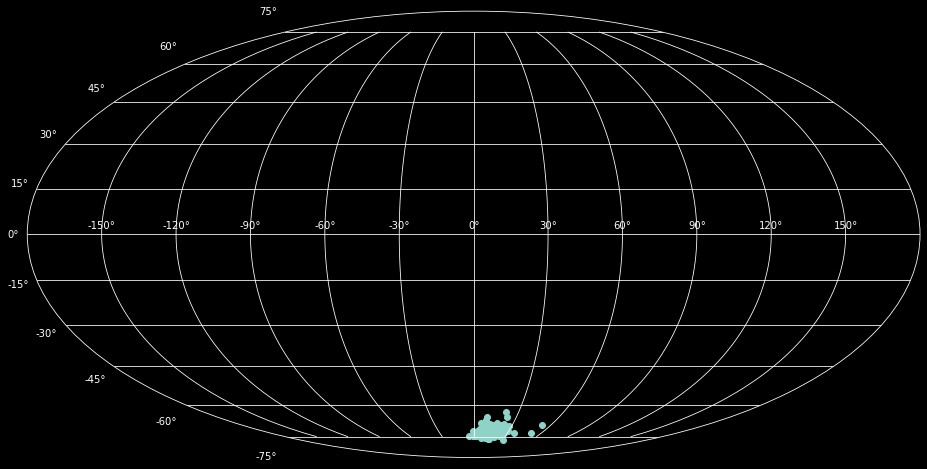

In [4]:
plt.style.use('dark_background')
fig = plt.figure(figsize=(16, 9))
ax = fig.add_subplot(111, projection="mollweide")
ax.scatter([df['RA']* np.pi/180], [df['Decl']* np.pi/180])
ax.grid()

plt.savefig('Mollweide projection.png')

# P-L Diagrams

Plot the Magnitude vs log(Period) for V and I bands. Observe that a linear fit can be done to obtain the period magnitude relation for each band separately. Use scipy's curve fit module to obtain the relation for both V and I band. The P-L relation is of the form <br><br>
$m_{\lambda} = a_{\lambda}log(P) + I_{\lambda}$ <br><br>
where $m_{\lambda}$ is the apparent magnitude, $a_{\lambda}$ is the slope, P is period and $I_{\lambda}$ is the intercept

In [5]:
df['log_P_1'] = np.log(df['P_1'])
df

,index,ID,RA,Decl,I,V,P_1,log_P_1
0,0,OGLE-SMC-CEP-0001,5.032792,-73.451500,17.314,17.897,1.128258,0.120675
1,1,OGLE-SMC-CEP-0005,5.474500,-71.627028,17.196,17.768,1.287411,0.252634
2,2,OGLE-SMC-CEP-0006,5.484833,-72.084472,17.120,17.770,1.484773,0.395262
3,4,OGLE-SMC-CEP-0009,5.606667,-72.215694,16.814,17.384,1.639233,0.494228
4,5,OGLE-SMC-CEP-0010,5.622042,-72.095472,16.976,17.515,1.442611,0.366455
...,...,...,...,...,...,...,...,...
2632,2741,OGLE-SMC-CEP-4967,14.144167,-76.079667,17.328,18.067,1.012830,0.012748
2633,2749,OGLE-SMC-CEP-4983,27.668750,-69.496389,15.224,15.834,4.372303,1.475290
2634,2750,OGLE-SMC-CEP-4985,29.198917,-72.173028,14.063,14.929,8.040087,2.084440
2635,2752,OGLE-SMC-CEP-4987,52.893333,-69.006056,15.738,16.458,2.928475,1.074482


### Plot of Magnitude vs log(Period) for V and I bands

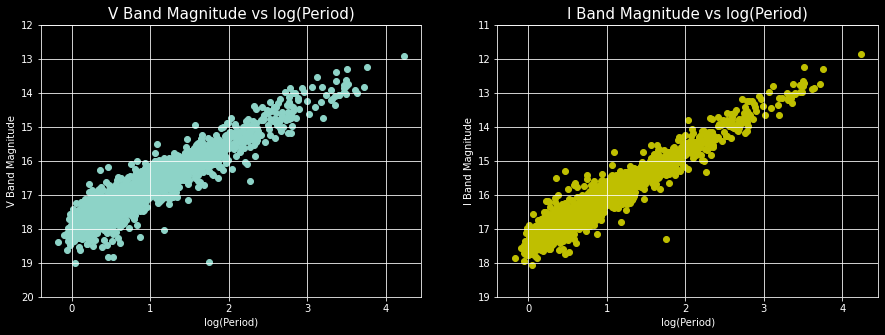

In [6]:
fig,ax=plt.subplots(1,2,figsize=[15,5])
plt.style.use('dark_background')

# V Band Magnitude
ax[0].scatter(df['log_P_1'], df['V'])
ax[0].set_title("V Band Magnitude vs log(Period)",fontsize=15)
ax[0].set_ylabel("V Band Magnitude")
ax[0].set_ylim(20,12) 
ax[0].set_xlabel("log(Period)")
ax[0].grid()

# I Band Magnitude
ax[1].scatter(df['log_P_1'], df['I'], c='y')
ax[1].set_title("I Band Magnitude vs log(Period)",fontsize=15)
ax[1].set_ylabel("I Band Magnitude")
ax[1].set_ylim(19,11) 
ax[1].set_xlabel("log(Period)")
ax[1].grid()

An apparent Linear Fit can be observed from the scatter plot above.

### Linear Fitting 
using `scipy.optimize.curve_fit` function

In [7]:
def linear(log_P, a, I):
    return a*log_P + I

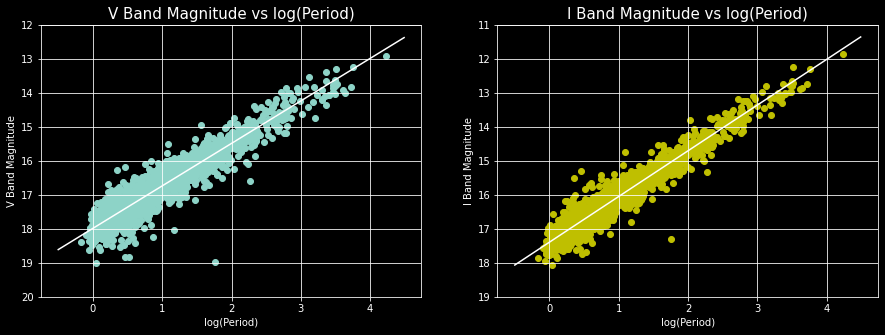

In [8]:
log_P_values=np.arange(-0.5,4.5,0.01)
fig,ax=plt.subplots(1,2,figsize=[15,5])
plt.style.use('dark_background')

# V Band Magnitude
popt, _ = curve_fit(linear,df['log_P_1'] , df['V'])
a,I=popt
ax[0].scatter(df['log_P_1'], df['V'])
ax[0].plot(log_P_values,linear(log_P_values,a,I),'w-',label='Linear Fit')
ax[0].set_title("V Band Magnitude vs log(Period)",fontsize=15)
ax[0].set_ylabel("V Band Magnitude")
ax[0].set_ylim(20,12) 
ax[0].set_xlabel("log(Period)")
Slope_V = a
Intercept_V = I
ax[0].grid()

# I Band Magnitude
popt, _ = curve_fit(linear,df['log_P_1'] , df['I'])
a,I=popt
ax[1].scatter(df['log_P_1'], df['I'], c='y')
ax[1].plot(log_P_values,linear(log_P_values,a,I),'w-',label='Linear Fit')
ax[1].set_title("I Band Magnitude vs log(Period)",fontsize=15)
ax[1].set_ylabel("I Band Magnitude")
ax[1].set_ylim(19,11) 
ax[1].set_xlabel("log(Period)")
Slope_I = a
Intercept_I = I
ax[1].grid()

plt.savefig('P-L Diagram.png')

In [9]:
print("For V Band: Slope =",Slope_V, "Intercept =",Intercept_V)
print("For I Band: Slope =",Slope_I, "Intercept =",Intercept_I)

For V Band: Slope = -1.250511937425567 Intercept = 17.98537783574373
For I Band: Slope = -1.3453561459852155 Intercept = 17.392207055244064


# Deviation

From the P-L diagrams, you can observe that there are quite a few stars that deviate from the linear fit, in both bands. A naive attempt at quantifying the deviation from the P-L relation would be by splitting the region the cepheids are contained in into multiple patches and calculating the fit parameters in each patch. Assume that the change in slope value is negligible. This leaves only the intercept, implying that the new fit is a vertical offset from the global fit done earlier. <br><br>

Divide the SMC region into 25 patches. You can do this by simply partitioning the RA and Dec ranges into 5 parts each. Each patch would look somewhat similar to the reference image below (not related to SMC data). Make sure that you do not include outliers while partitioning RA and Dec. Quantiles can be used to change the range containing 5% to 95% of all entries. <br><br>

![Sky Grid](Sky_Grid.png)

Write a function to perform a linear fit to both V and I bands in each patch and return the intercept values. We calculate the deviation as <br><br>

$D_{V-I} = (GI_V - I_V) - (GI_I - I_I)$ <br><br>

where GI is the Grid Intercept (intercept values in each grid) and I is the intercept (global intercept from the previous part). The bands are in given in the subscripts. You will obtain 25 values of $D_{V-I}$, one for each patch. Plot a histogram of these values.

### SMC Region Plot

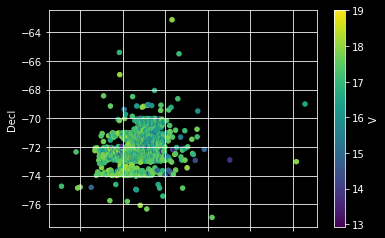

In [10]:
ax = df.plot.scatter(x='RA',y='Decl',c='V',colormap='viridis')
ax.grid()

### Detection and removal of Outliers
Quantiles are used to change the range containing 15% to 85% of all entries, so that minimum patches get 0 or 1 cepheids.

In [11]:
Q1 = df.quantile(0.15)
Q3 = df.quantile(0.85)
IQR = Q3-Q1
print('InterQuartile Range')
print(IQR)

InterQuartile Range
index      1917.800000
RA            5.772367
Decl          1.805289
I             1.781800
V             1.694200
P_1           3.386467
log_P_1       1.263450
dtype: float64


In [12]:
df = df[~((df<(Q1-1.5*IQR))|(df>(Q3+1.5*IQR))).any(axis=1)]
df.shape

C:\Users\HP\AppData\Local\Temp/ipykernel_29744/192629432.py:1: FutureWarning: Automatic reindexing on DataFrame vs Series comparisons is deprecated and will raise ValueError in a future version.  Do `left, right = left.align(right, axis=1, copy=False)` before e.g. `left == right`
  df = df[~((df<(Q1-1.5*IQR))|(df>(Q3+1.5*IQR))).any(axis=1)]


(2498, 8)

### Generation of the 25 Patches from the SMC Region

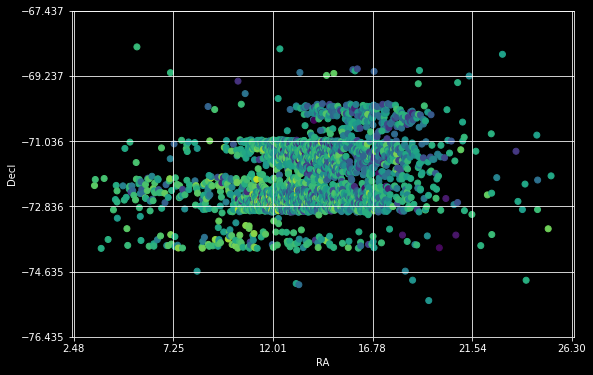

In [13]:
fig,ax=plt.subplots(1,1,figsize=[9,6])
ax.scatter(df['RA'], df['Decl'],c=df['V'])

# Dividing the SMC Region into 25 Patches (Graphically)
sigma = 1
patches = 5
major_ticks_RA=np.linspace(df['RA'].min()-sigma, df['RA'].max()+sigma, patches+1)
major_ticks_Decl=np.linspace(df['Decl'].min()-sigma, df['Decl'].max()+sigma, patches+1)
ax.set_xticks(major_ticks_RA)
ax.set_yticks(major_ticks_Decl)
ax.set_xlabel("RA")
ax.set_ylabel("Decl")
ax.grid()

In [14]:
# Dividing the SMC Region into 25 Patches (Numerically)
df_list = []
for i in range (-75,-70,1):
    for j in range(4, 24, 4):
        df_list.append(df[(df['Decl'] >= i + 0.5) & (df['Decl'] <= i+1.5) & (df['RA'] >= j) & (df['RA'] <= j+4)])

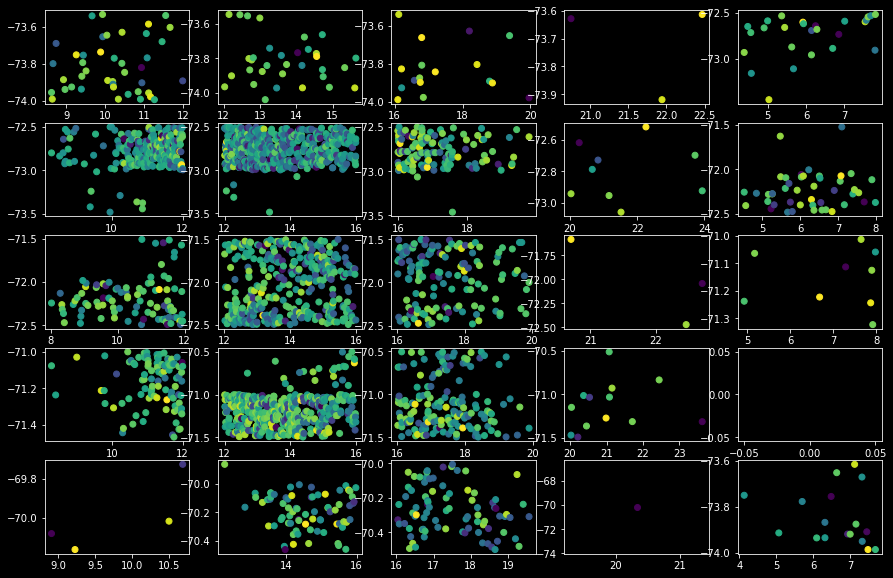

In [15]:
fig,ax=plt.subplots(5,5,figsize=[15,10])
for k in range(len(df_list)):
    x = np.array(df_list[k]['RA'])
    y = np.array(df_list[k]['Decl'])
    plt.scatter(x,y,c=df_list[k]['V'])
    plt.subplot(5, 5, k+1)
plt.show()

The above graphs plot the cepheids in the 25 Patches by their RA and Decl values.

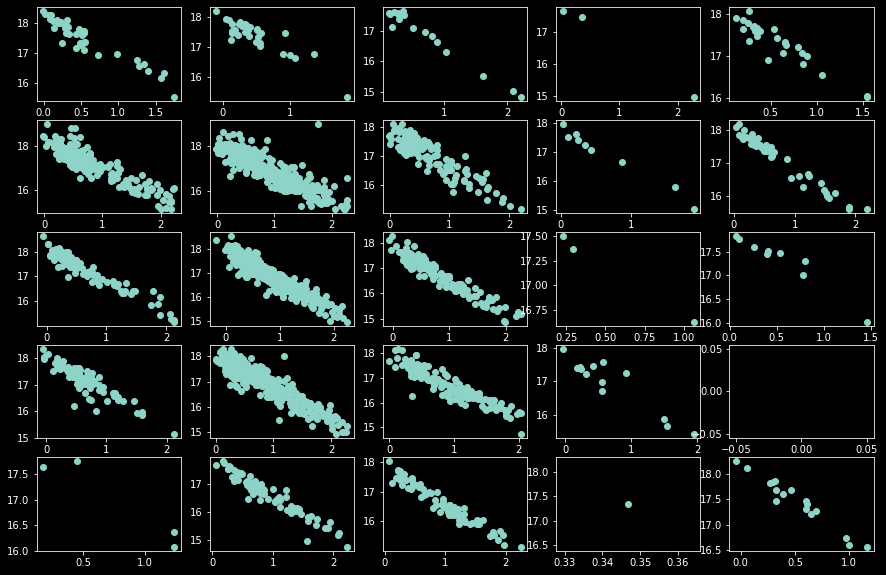

In [16]:
fig,ax=plt.subplots(5,5,figsize=[15,10])
for k in range(len(df_list)):
    x = np.array(df_list[k]['log_P_1'])
    y = np.array(df_list[k]['V'])
    plt.scatter(x,y)
    plt.subplot(5, 5, k+1)
plt.show()

The above plots are the V Band Magnitude vs log(Period) of the stars in the 25 patches. Similar plots will be obtained for I Band Magnitude vs log(Period). We can observe an apparent Linear Fit.

### Calculation of Linear Fit Intercept Values
As is visible from the Patch Plots above, some patches have 0 or 1 cepheids. A Linear Fit cannot be obtained for these regions. Thus, $GI_V$ and $GI_I$ values of theses regions are not defined due to lack of sufficient data.

In [17]:
GI_V = []
GI_I = []
for k in range(len(df_list)):
    if len(df_list[k]) == 0 or len(df_list[k]) == 1:
        GI_V.append('insufficient data')
        GI_I.append('insufficient data')
        continue
    else:
        log_P_values=np.arange(-0.5,4.5,0.01)
        popt, _ = curve_fit(linear,df_list[k]['log_P_1'] , df_list[k]['V'])
        a,I=popt
        GI_V.append(I)
        popt, _ = curve_fit(linear,df_list[k]['log_P_1'] , df_list[k]['I'])
        a,I=popt
        GI_I.append(I)

### Deviation Calculation
$$D_{V-I} = (GI_V - I_V) - (GI_I - I_I)$$

In [18]:
D_V_I = []
for l in range(25):
    if type(GI_V[l]) == np.float64:
        D_V_I.append((GI_V[l]-Intercept_V)-(GI_I[l]-Intercept_I))   
    else:
        D_V_I.append(0)
data = pd.DataFrame({'GI_V': GI_V,'GI_I': GI_I,'D_V_I': D_V_I})
pd.DataFrame(data)

,GI_V,GI_I,D_V_I
0,18.211305,17.618066,0.000068
1,18.20627,17.61965,-0.006551
2,17.927223,17.349578,-0.015526
3,17.829891,17.255601,-0.018881
4,17.78129,17.16121,0.026910
5,18.049926,17.491993,-0.035238
6,18.217623,17.565883,0.058570
7,18.032912,17.432369,0.007372
8,17.848505,17.274082,-0.018747
9,17.822843,17.202719,0.026954


### Histogram

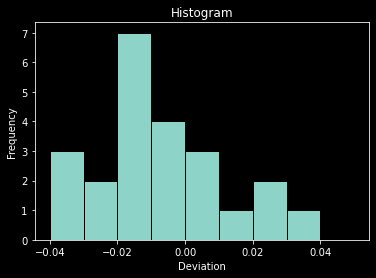

In [19]:
bins = list(np.arange(-0.04,0.06,0.01))
plt.hist(D_V_I, bins, edgecolor='k')
plt.title("Histogram")
plt.xlabel("Deviation")
plt.ylabel("Frequency")
plt.show()

### Bar Graph

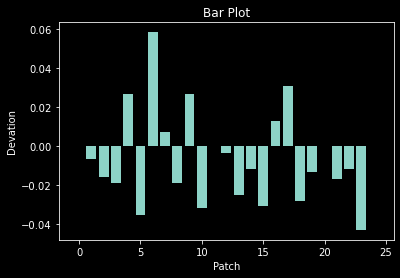

In [20]:
plt.bar(list(range(25)), D_V_I)
plt.title("Bar Plot")
plt.xlabel("Patch")
plt.ylabel("Devation")
plt.show()

## Wesenheit Index

Deviations from P-L relation may occur due to a phenomena called interstellar extinction. The Wesenheit Index, defined as `W = I - 1.55(V - I)` automatically takes care of extinction. Show a plot of W vs log(P) for the given data.

$$W = I - 1.55(V - I)$$

In [21]:
df['W'] = df['I'] - 1.55 * (df['V'] - df['I'])
df

C:\Users\HP\AppData\Local\Temp/ipykernel_29744/2423638991.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['W'] = df['I'] - 1.55 * (df['V'] - df['I'])


,index,ID,RA,Decl,I,V,P_1,log_P_1,W
0,0,OGLE-SMC-CEP-0001,5.032792,-73.451500,17.314,17.897,1.128258,0.120675,16.41035
1,1,OGLE-SMC-CEP-0005,5.474500,-71.627028,17.196,17.768,1.287411,0.252634,16.30940
2,2,OGLE-SMC-CEP-0006,5.484833,-72.084472,17.120,17.770,1.484773,0.395262,16.11250
3,4,OGLE-SMC-CEP-0009,5.606667,-72.215694,16.814,17.384,1.639233,0.494228,15.93050
4,5,OGLE-SMC-CEP-0010,5.622042,-72.095472,16.976,17.515,1.442611,0.366455,16.14055
...,...,...,...,...,...,...,...,...,...
2619,2728,OGLE-SMC-CEP-4921,25.165417,-73.454583,17.489,18.073,1.149470,0.139301,16.58380
2620,2729,OGLE-SMC-CEP-4924,25.302667,-71.995222,16.664,17.277,1.399182,0.335888,15.71385
2630,2739,OGLE-SMC-CEP-4962,9.226958,-70.165000,17.037,17.745,1.569430,0.450713,15.93960
2631,2740,OGLE-SMC-CEP-4963,11.305292,-71.797833,17.125,17.848,1.063328,0.061403,16.00435


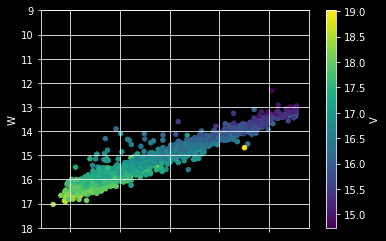

In [22]:
ax = df.plot.scatter(x='log_P_1',y='W',c='V',colormap='viridis')
ax.set_ylim(18,9) 
ax.grid()

plt.savefig('W-P Relation.png')

### My Understanding of the Problem-Statement: 
- The P-L Relations and W-P relations in the V and I Bands make Cepheid Variables the Standard Candles and cosmic benchmarks for galactic and extragalactic distances. 
- These P-L Relations are considered to be fundamental and are also obeyed by small independent patches of cepheids in a cluster and gives miniscule deviations.
- The W-P formulation is derived from the more genneral PL relation. It has the advantage to be reddening−free by construction and to include the colour (and in turn the temperature) information for each individual Cepheid.

### Hints and References:

Magnitude system: [Wikipedia](https://en.wikipedia.org/wiki/Magnitude_(astronomy%29) <br>
Pandas: [Pandas](https://pandas.pydata.org/docs/user_guide/index.html)<br>
Interstellar Extinction: [Wikipedia](https://en.wikipedia.org/wiki/Extinction_(astronomy%29)